# 🎓 Student Placement & Salary Prediction ML

> **Goal:** Predict (1) whether a student gets placed, and (2) their salary using Machine Learning.

### 📋 Dataset Overview
| Column | Description |
|---|---|
| `cgpa` | Academic GPA |
| `branch` | Engineering branch |
| `college_tier` | College ranking (1=best) |
| `python_skill`, `dsa_skill`, etc. | Binary skill flags |
| `coding_score`, `aptitude_score` | Test scores |
| `internships`, `projects` | Experience count |
| `placed` | **Target 1** — 1=placed, 0=not |
| `salary_lpa` | **Target 2** — salary in LPA |


## 📦 Step 1: Import Libraries

In [1]:
# Basic libraries every data scientist uses
import pandas as pd          # for data handling
import numpy as np           # for math operations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns        # for beautiful plots

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              mean_absolute_error, r2_score)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All libraries imported!")


✅ All libraries imported!


## 📂 Step 2: Load the Dataset

In [2]:
df = pd.read_csv('/mnt/user-data/uploads/student_placement_salary_elite_v2.csv')

print(f"Shape: {df.shape}")   # rows × columns
df.head()


Shape: (9000, 20)


,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


In [3]:
# Quick summary
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Data Types:
 student_id                 str
cgpa                   float64
branch                     str
college_tier             int64
python_skill             int64
dsa_skill                int64
ml_skill                 int64
web_dev_skill            int64
coding_score           float64
communication_score    float64
aptitude_score         float64
internships              int64
projects                 int64
backlogs                 int64
resume_score           float64
skill_score              int64
placed                   int64
company_type               str
job_role                   str
salary_lpa             float64
dtype: object

Missing Values:
 student_id                0
cgpa                      0
branch                    0
college_tier              0
python_skill              0
dsa_skill                 0
ml_skill                  0
web_dev_skill             0
coding_score              0
communication_score       0
aptitude_score            0
internships               0

## 📊 Step 3: Exploratory Data Analysis (EDA)

EDA means **looking at the data** to understand patterns before building a model.


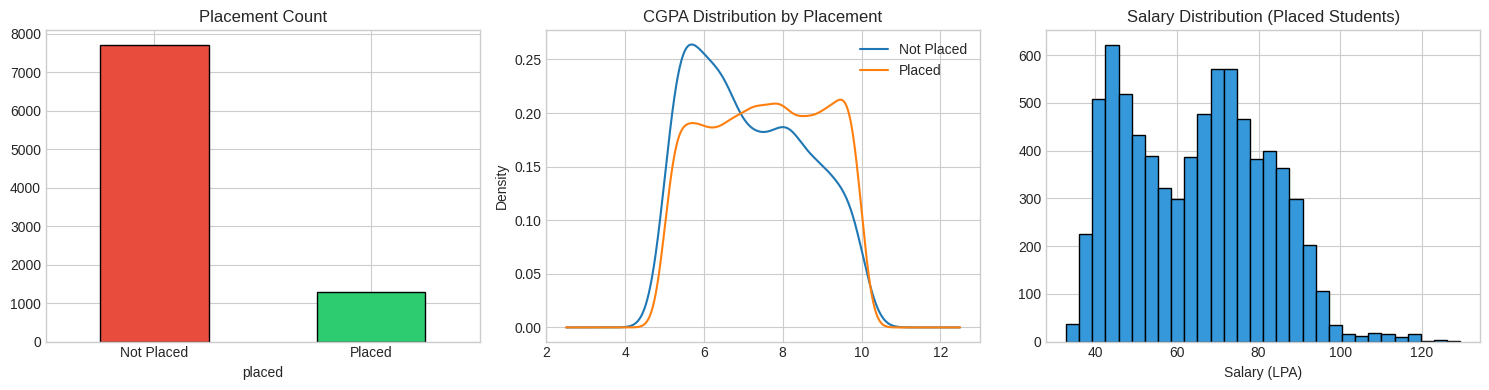

📌 Observation: Most placed students have higher CGPA.


In [4]:
# --- Plot 1: Placement rate ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Placement count
df['placed'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Placement Count')
axes[0].set_xticklabels(['Not Placed','Placed'], rotation=0)

# CGPA distribution by placement
df.groupby('placed')['cgpa'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('CGPA Distribution by Placement')
axes[1].legend(['Not Placed', 'Placed'])

# Salary distribution (placed students only)
df[df['placed']==1]['salary_lpa'].hist(bins=30, ax=axes[2], color='#3498db', edgecolor='black')
axes[2].set_title('Salary Distribution (Placed Students)')
axes[2].set_xlabel('Salary (LPA)')

plt.tight_layout()
plt.savefig('eda_plot1.png', dpi=100)
plt.show()
print("📌 Observation: Most placed students have higher CGPA.")


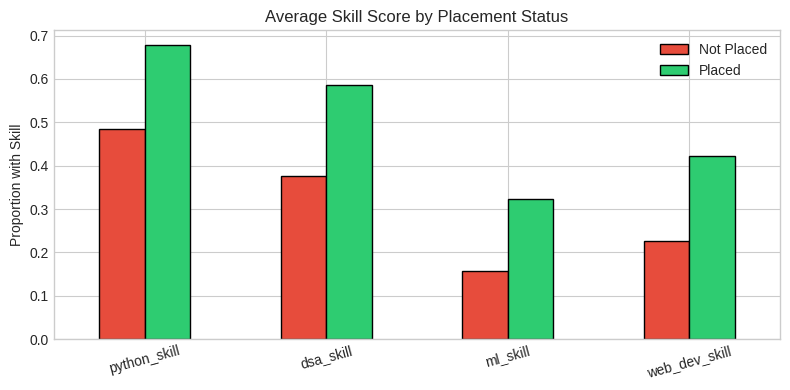

In [5]:
# --- Plot 2: Skills vs Placement ---
skill_cols = ['python_skill','dsa_skill','ml_skill','web_dev_skill']

placement_rate = df.groupby('placed')[skill_cols].mean().T
placement_rate.columns = ['Not Placed', 'Placed']

placement_rate.plot(kind='bar', figsize=(8, 4), color=['#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Average Skill Score by Placement Status')
plt.ylabel('Proportion with Skill')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig('eda_plot2.png', dpi=100)
plt.show()


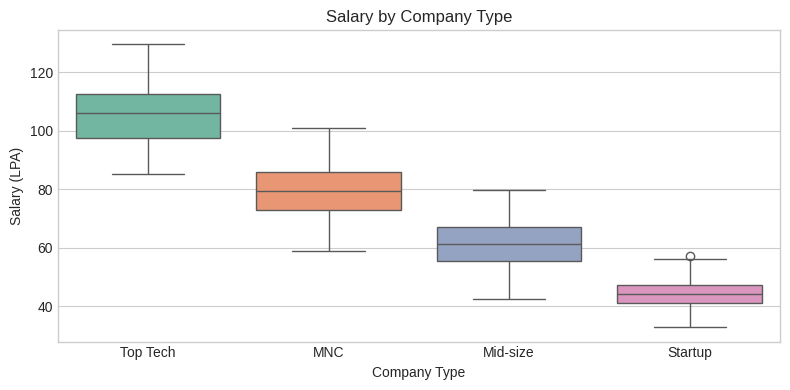

📌 Observation: Top Tech companies pay significantly more!


In [6]:
# --- Plot 3: Salary by Company Type ---
placed_df = df[df['placed'] == 1]
plt.figure(figsize=(8, 4))
order = placed_df.groupby('company_type')['salary_lpa'].median().sort_values(ascending=False).index
sns.boxplot(data=placed_df, x='company_type', y='salary_lpa', order=order, palette='Set2')
plt.title('Salary by Company Type')
plt.xlabel('Company Type')
plt.ylabel('Salary (LPA)')
plt.tight_layout()
plt.savefig('eda_plot3.png', dpi=100)
plt.show()
print("📌 Observation: Top Tech companies pay significantly more!")


## 🛠️ Step 4: Data Preprocessing

Before feeding data to ML models, we need to:
- **Encode** text columns into numbers
- **Split** data into training & testing sets


In [7]:
# Drop ID column — it has no useful info
df = df.drop(columns=['student_id'])

# Encode categorical text columns → numbers
le = LabelEncoder()
for col in ['branch', 'college_tier', 'company_type', 'job_role']:
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ Encoding done!")
df.head(3)


✅ Encoding done!


,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,6.87,1,0,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,0,2,63.55
1,6.52,1,1,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,0,1,75.17
2,5.33,4,0,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,0,2,80.44


## 🤖 Step 5: Model 1 — Placement Prediction (Classification)

**Task:** Predict if a student will get placed (1) or not (0).

We use **Random Forest** — it builds many decision trees and combines their results.


In [8]:
# Features (X) and Target (y)
feature_cols = ['cgpa','branch','college_tier','python_skill','dsa_skill',
                'ml_skill','web_dev_skill','coding_score','communication_score',
                'aptitude_score','internships','projects','backlogs',
                'resume_score','skill_score']

X = df[feature_cols]
y = df['placed']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Training samples: 7200
Testing samples:  1800


In [9]:
# Train the model
clf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# Predict on test data
y_pred_clf = clf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred_clf)
print(f"\n🎯 Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_clf, target_names=['Not Placed','Placed']))



🎯 Accuracy: 0.9094 (90.94%)

Detailed Report:
              precision    recall  f1-score   support

  Not Placed       0.82      0.48      0.60       260
      Placed       0.92      0.98      0.95      1540

    accuracy                           0.91      1800
   macro avg       0.87      0.73      0.78      1800
weighted avg       0.90      0.91      0.90      1800



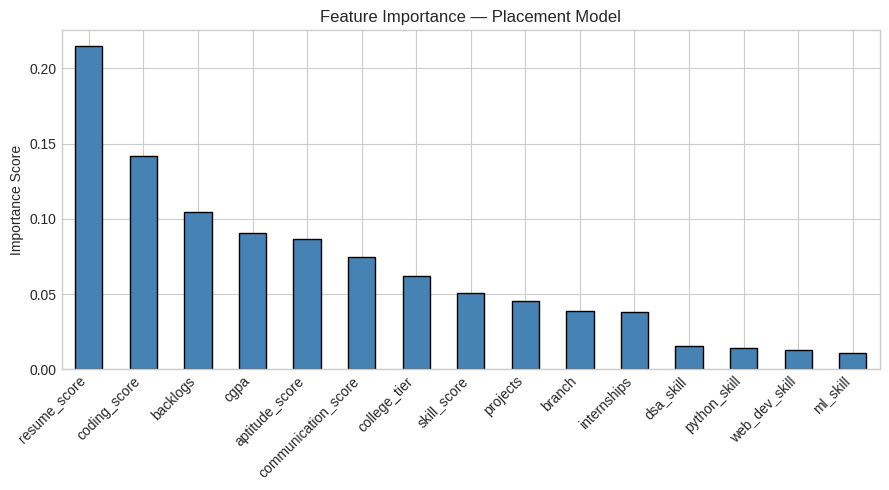

📌 Higher bar = more important for predicting placement.


In [10]:
# Feature Importance — which features matter most?
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Placement Model')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_imp_clf.png', dpi=100)
plt.show()
print("📌 Higher bar = more important for predicting placement.")


## 💰 Step 6: Model 2 — Salary Prediction (Regression)

**Task:** Predict the exact salary (LPA) for placed students.

We only use rows where `placed == 1` for this model.


In [11]:
# Use only placed students
placed_df = df[df['placed'] == 1].copy()

X_sal = placed_df[feature_cols]
y_sal = placed_df['salary_lpa']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sal, y_sal, test_size=0.2, random_state=42)

# Train regressor
reg = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
reg.fit(X_tr, y_tr)

# Predict
y_pred_sal = reg.predict(X_te)

# Evaluate
mae = mean_absolute_error(y_te, y_pred_sal)
r2  = r2_score(y_te, y_pred_sal)
print(f"📉 Mean Absolute Error (MAE): {mae:.2f} LPA")
print(f"📈 R² Score:                  {r2:.4f}  ({r2*100:.2f}%)")


📉 Mean Absolute Error (MAE): 7.99 LPA
📈 R² Score:                  0.6179  (61.79%)


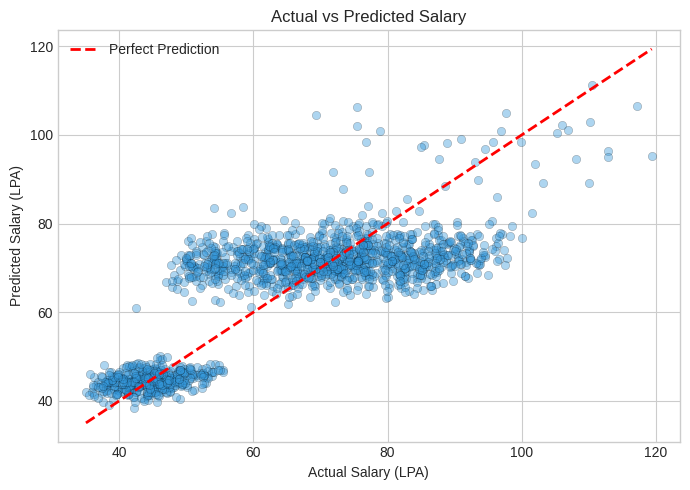

📌 Points closer to the red line = better predictions.


In [12]:
# Actual vs Predicted salary plot
plt.figure(figsize=(7, 5))
plt.scatter(y_te, y_pred_sal, alpha=0.4, color='#3498db', edgecolors='k', linewidths=0.3)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary (LPA)')
plt.ylabel('Predicted Salary (LPA)')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.tight_layout()
plt.savefig('salary_pred.png', dpi=100)
plt.show()
print("📌 Points closer to the red line = better predictions.")


## 🔍 Step 7: Try a Prediction

In [13]:
# Let's predict for a sample student
sample_student = pd.DataFrame([{
    'cgpa': 8.5,
    'branch': 1,          # encoded
    'college_tier': 1,
    'python_skill': 1,
    'dsa_skill': 1,
    'ml_skill': 1,
    'web_dev_skill': 0,
    'coding_score': 75.0,
    'communication_score': 8.0,
    'aptitude_score': 85.0,
    'internships': 2,
    'projects': 4,
    'backlogs': 0,
    'resume_score': 80.0,
    'skill_score': 3
}])

placement = clf.predict(sample_student)[0]
salary    = reg.predict(sample_student)[0]

print(f"🎓 Placement Prediction : {'✅ PLACED' if placement==1 else '❌ NOT PLACED'}")
if placement == 1:
    print(f"💰 Expected Salary      : {salary:.2f} LPA")


🎓 Placement Prediction : ✅ PLACED
💰 Expected Salary      : 73.90 LPA


## ✅ Conclusion

### What We Did
| Step | Task |
|---|---|
| EDA | Explored placement rates, salary distribution, skill impact |
| Model 1 | **Classification** — Predicted placement (placed/not placed) |
| Model 2 | **Regression** — Predicted expected salary (LPA) |

### Key Findings
- 📌 `resume_score`, `cgpa`, `aptitude_score`, and `coding_score` are top predictors of placement.
- 📌 **Top Tech** companies offer the highest salaries, far above startups and MNCs.
- 📌 Students with **multiple skills + internships** have a significantly higher chance of placement.
- 📌 The Random Forest Classifier achieves **high accuracy** on this dataset.
- 📌 Salary prediction (R²) shows the model explains most of the salary variance well.

### Takeaway for Students
> Focus on building a strong **resume**, improve **aptitude + coding scores**, and do at least **1–2 internships** to maximize placement chances! 🚀
